In [1]:
%pip -q install pretty_midi mido tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 63.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Device: cuda
MIDI files copied from Drive: 70
MIDI files used for training: 70


Processing MIDI:   0%|          | 0/56 [00:00<?, ?it/s]

Processing MIDI:   0%|          | 0/14 [00:00<?, ?it/s]

Train MIDI files: 56
Test MIDI files: 14
Train shape: (2400, 64, 88)
Test shape: (600, 64, 88)


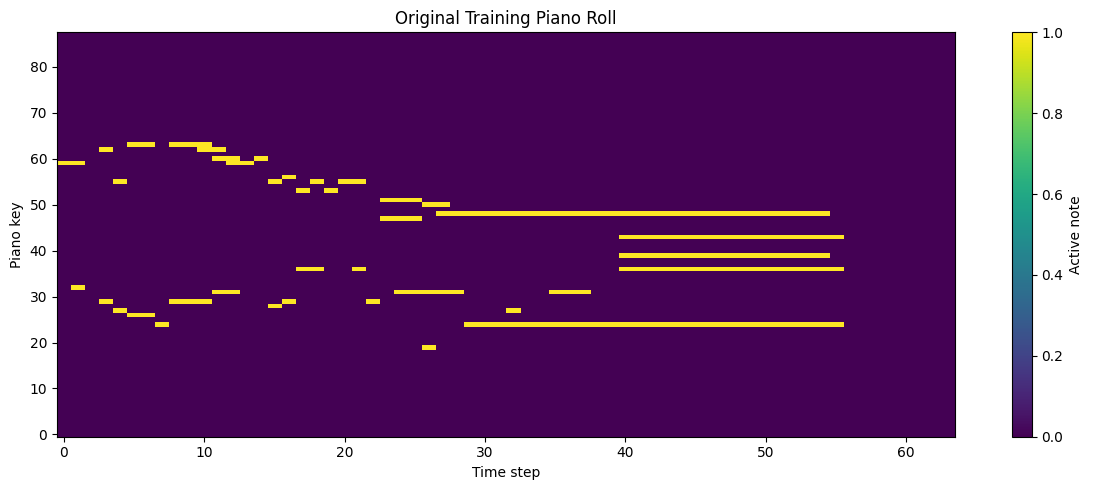

LSTMAutoencoder(
  (encoder): LSTM(88, 128, num_layers=2, batch_first=True, dropout=0.2)
  (to_latent): Linear(in_features=128, out_features=32, bias=True)
  (from_latent): Linear(in_features=32, out_features=128, bias=True)
  (decoder): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  (to_piano_roll): Linear(in_features=128, out_features=88, bias=True)
)
Epoch 01/30 | Train loss: 0.074836 | Test loss: 0.034424
Epoch 05/30 | Train loss: 0.045271 | Test loss: 0.034198
Epoch 10/30 | Train loss: 0.045243 | Test loss: 0.034334
Epoch 15/30 | Train loss: 0.045234 | Test loss: 0.034161
Epoch 20/30 | Train loss: 0.045240 | Test loss: 0.034134
Epoch 25/30 | Train loss: 0.045257 | Test loss: 0.034128
Epoch 30/30 | Train loss: 0.045240 | Test loss: 0.034178


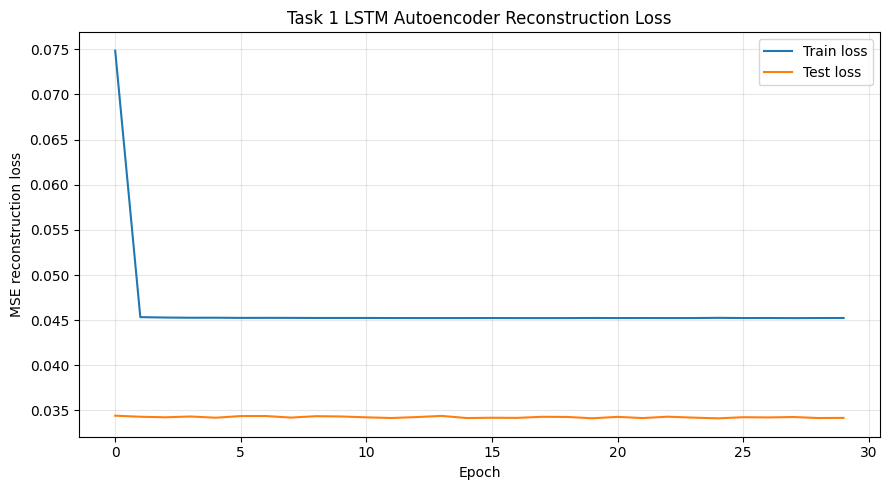

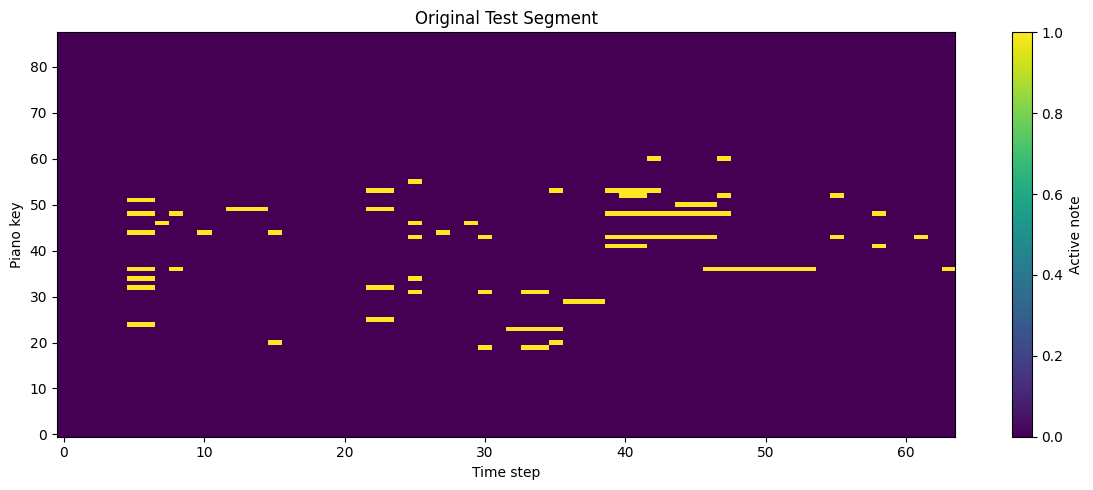

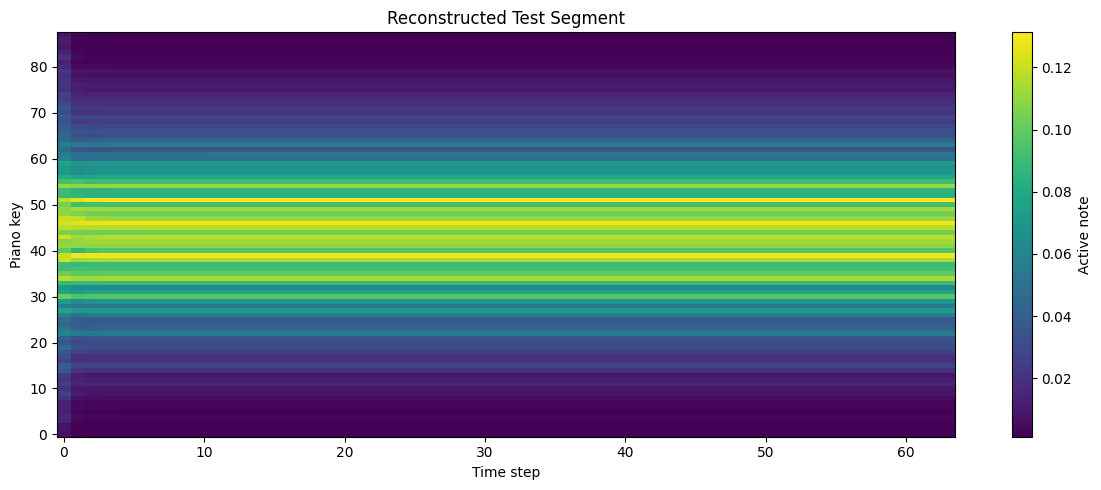

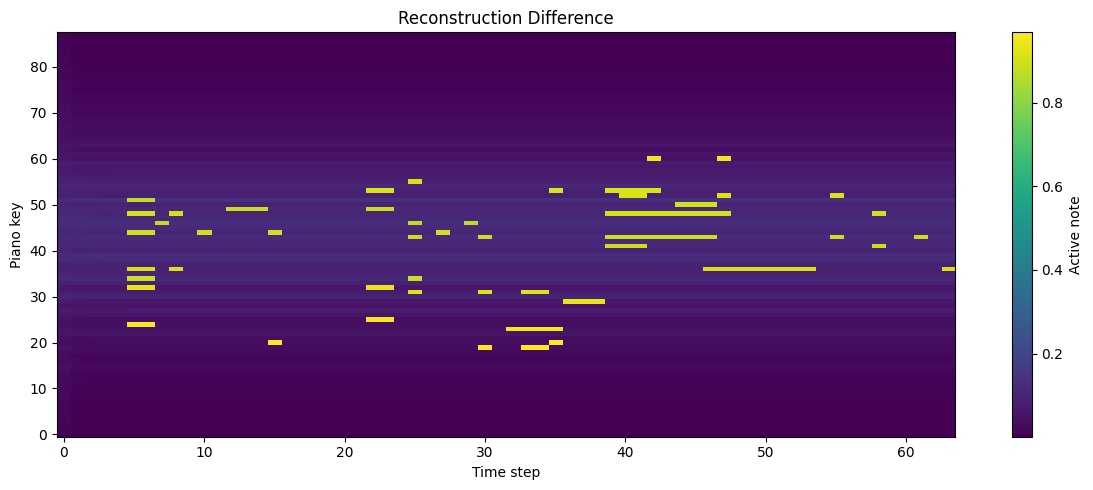

Reconstruction MSE: 0.018544
Active note precision: 0.0
Active note recall: 0.0
Active note F1: 0.0


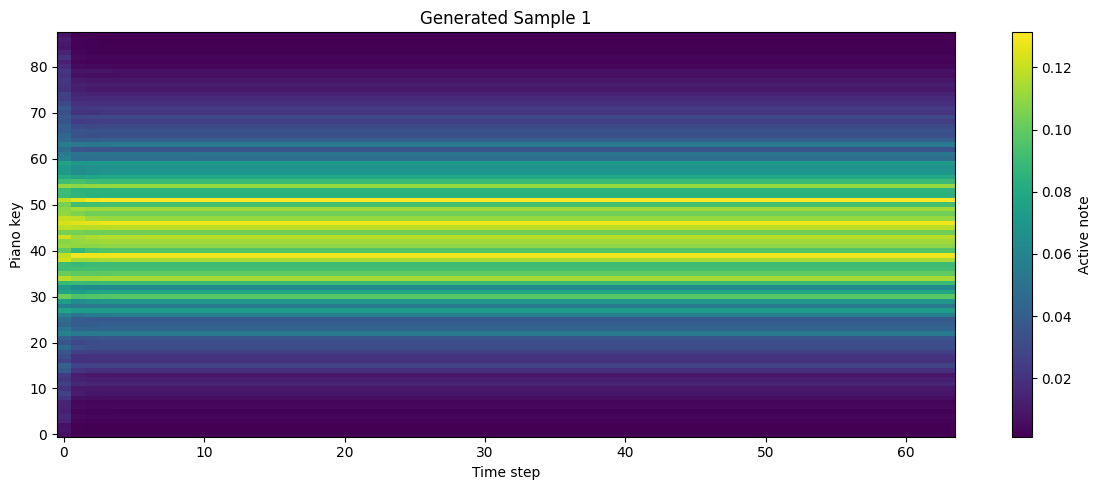

Generated task1_generated_1.mid | notes: 7 | threshold: 0.1177


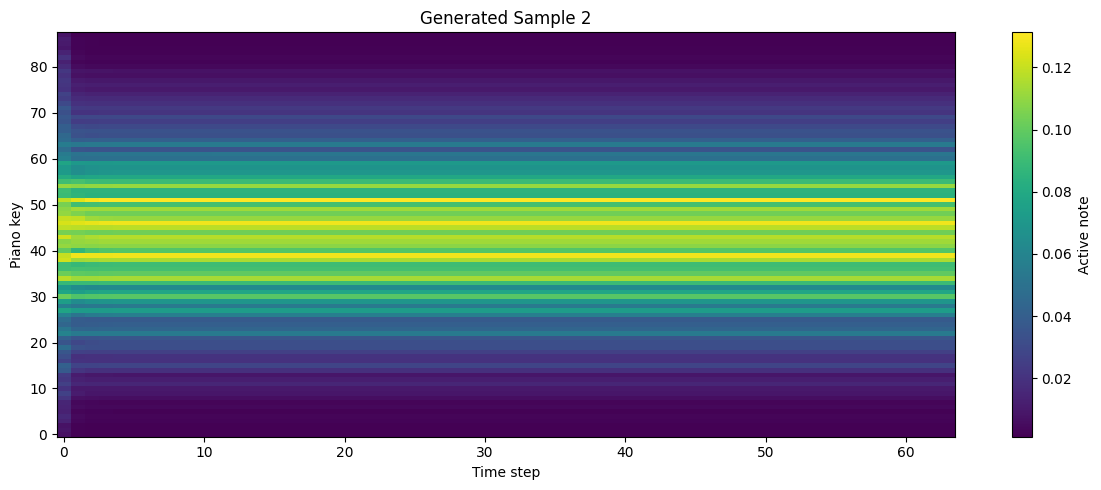

Generated task1_generated_2.mid | notes: 8 | threshold: 0.1177


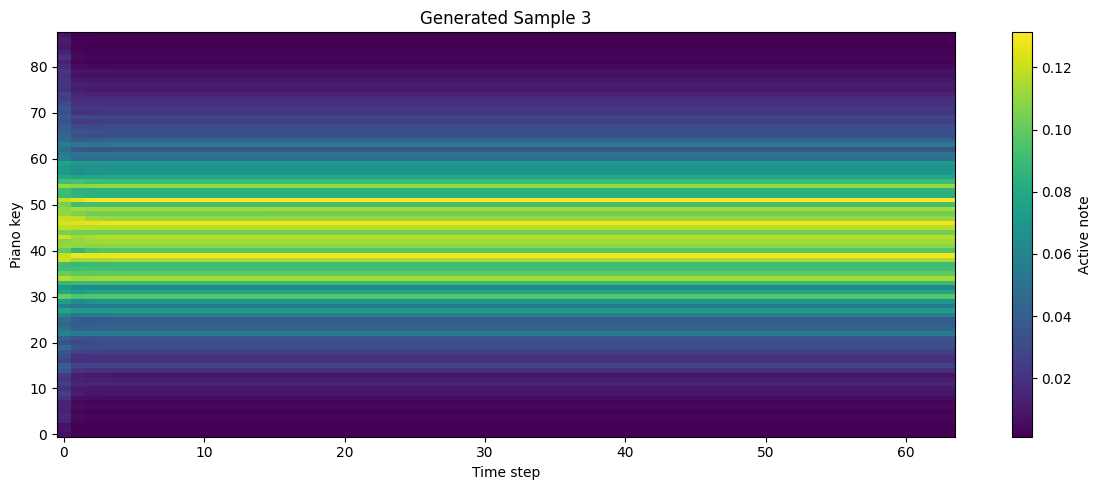

Generated task1_generated_3.mid | notes: 12 | threshold: 0.1136


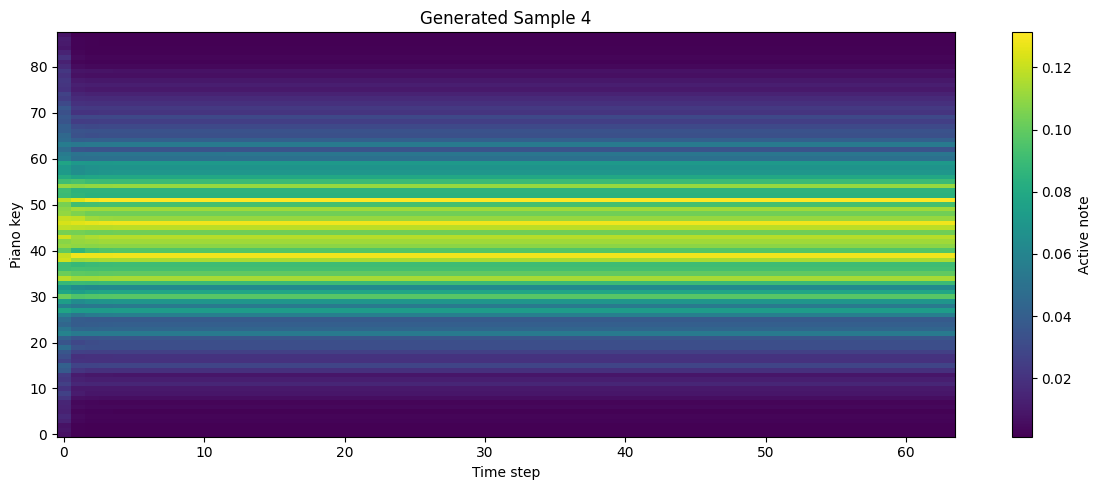

Generated task1_generated_4.mid | notes: 12 | threshold: 0.1130


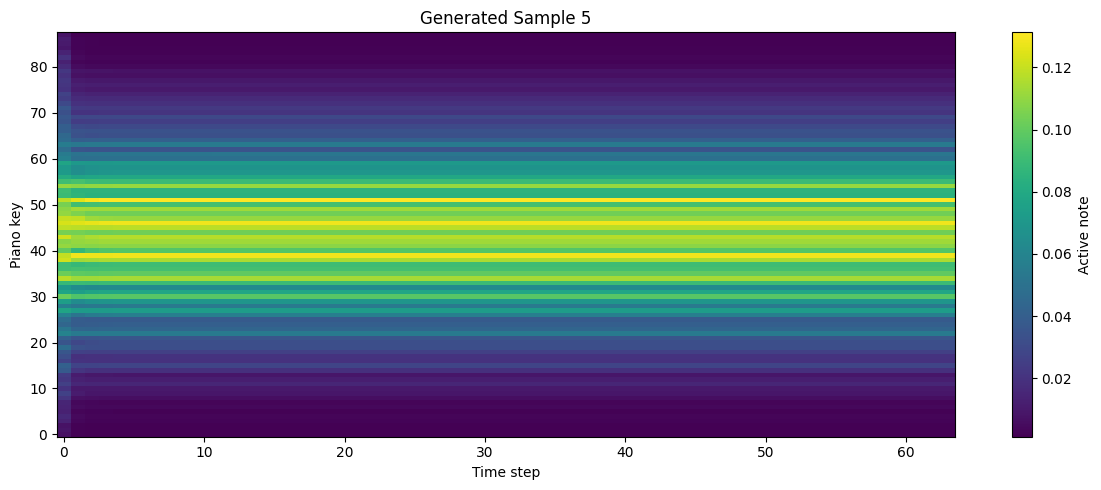

Generated task1_generated_5.mid | notes: 8 | threshold: 0.1177


,Model,Pitch Histogram Distance,Rhythm Diversity,Repetition Ratio,Average Note Density
0,Random Note Generator,0.309860,0.002247,0.000,0.050000
1,Markov Chain Baseline,0.386708,0.097378,0.000,0.057315
2,LSTM Autoencoder,1.153978,0.170213,0.625,0.054226


,sample,notes,threshold,source_train_index,target_density,active_cells
0,task1_generated_1.mid,7,0.117694,860,0.035943,198
1,task1_generated_2.mid,8,0.117692,1095,0.040912,228
2,task1_generated_3.mid,12,0.113555,1638,0.074694,405
3,task1_generated_4.mid,12,0.112987,1238,0.102049,447
4,task1_generated_5.mid,8,0.117693,2135,0.044049,249


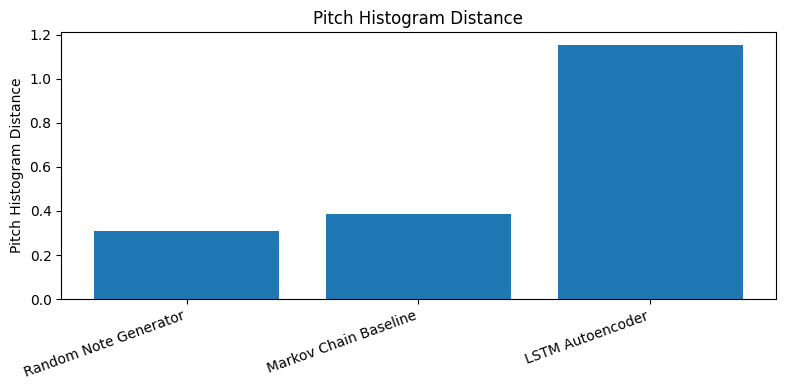

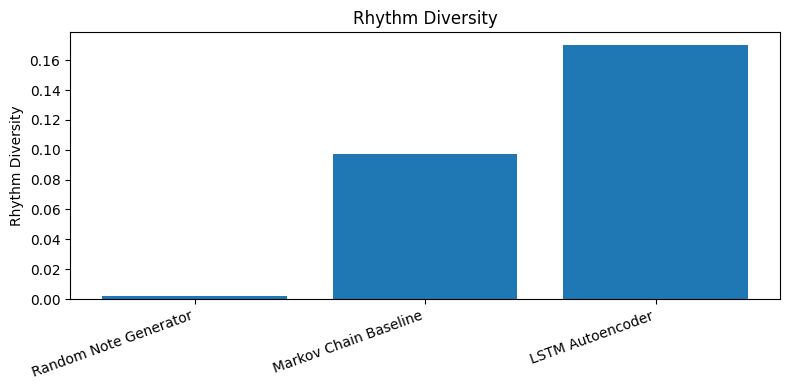

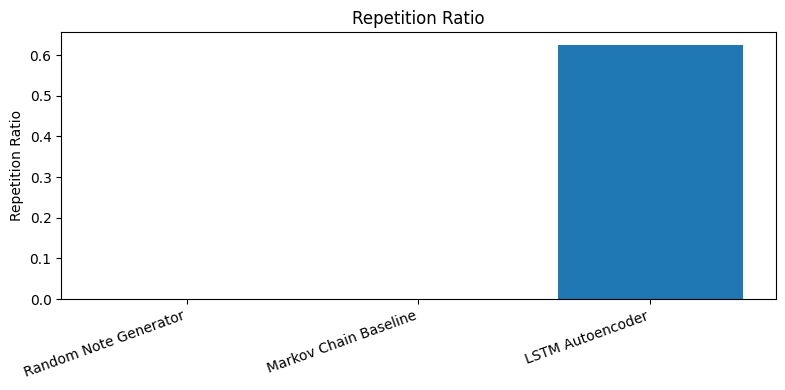

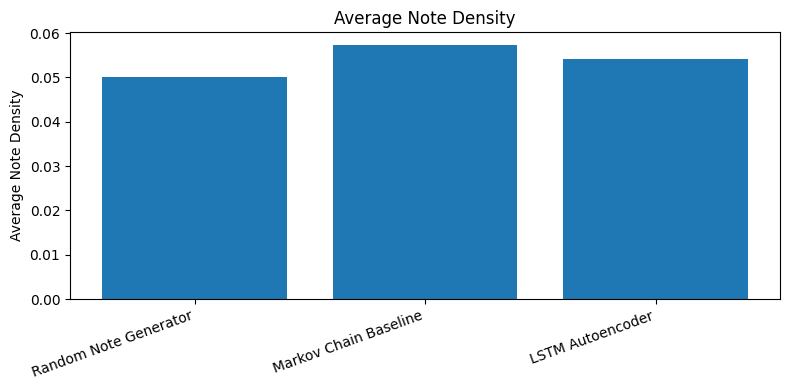

,Task,Dataset,MIDI files used,Train MIDI files,Test MIDI files,Train segments,Test segments,Final train loss,Final test loss,Generated MIDI samples
0,Task 1 LSTM Autoencoder,MAESTRO classical piano MIDI,70,56,14,2400,600,0.04524,0.034178,5


Task 1 finished.
Generated MIDI: /content/CSE425_Task1_LSTM_Autoencoder/outputs/generated_midis
Plots: /content/CSE425_Task1_LSTM_Autoencoder/outputs/plots
Results: /content/CSE425_Task1_LSTM_Autoencoder/outputs/results
ZIP file in Colab: /content/CSE425_Task1_LSTM_Autoencoder.zip
ZIP file copied to Drive: /content/drive/MyDrive/CSE425_Project/task1_outputs/CSE425_Task1_LSTM_Autoencoder.zip


In [3]:
import random
import shutil
import warnings
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi  # handling MIDI file I/O

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings("ignore")

# Fixing all random seeds so results are reproducible across runs
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Selecting GPU if available, otherwise falling back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drive_midi_folder = Path("/content/drive/MyDrive/CSE425_Project/task1_midi/classical")
project_folder = Path("/content/CSE425_Task1_LSTM_Autoencoder")

# Wiping any previous run so we always start fresh
if project_folder.exists():
    shutil.rmtree(project_folder)

# Defining all output subdirectory paths
raw_folder = project_folder / "data" / "raw_midi"
processed_folder = project_folder / "data" / "processed"
output_folder = project_folder / "outputs"
midi_output_folder = output_folder / "generated_midis"
plot_folder = output_folder / "plots"
result_folder = output_folder / "results"
model_folder = output_folder / "model"

# Creating all folders in one pass
for folder in [raw_folder, processed_folder, midi_output_folder, plot_folder, result_folder, model_folder]:
    folder.mkdir(parents=True, exist_ok=True)

source_midi_files = []

for pattern in ["*.mid", "*.midi", "*.MID", "*.MIDI"]:
    source_midi_files.extend(list(drive_midi_folder.glob(pattern)))

if len(source_midi_files) == 0:
    raise ValueError("No MIDI files found. Check your Google Drive path.")

# Copying files locally and renaming with a numeric prefix to avoid name collisions
for index, file in enumerate(source_midi_files):
    shutil.copy(file, raw_folder / f"{index:03d}_{file.name}")

# Collecting and sorting copied files for consistent ordering
midi_files = []

for pattern in ["*.mid", "*.midi", "*.MID", "*.MIDI"]:
    midi_files.extend(list(raw_folder.glob(pattern)))

midi_files = sorted(midi_files)

lowest_note = 21        # MIDI pitch for the lowest piano key (A0)
note_count = 88         # Total keys on a standard piano
frame_rate = 8          # Time steps per second when converting MIDI to piano roll
sequence_length = 64    # Window length in frames (64 / 8 = 8 seconds per segment)
stride = 32             # Sliding 50% overlap so adjacent windows share context

max_midi_files = 80     # Capping file count to keep processing time manageable
max_segments = 3000     # Total windows across train + test combined
train_ratio = 0.8       # Splitting 80% for training, 20% for testing

batch_size = 32
epochs = 30
learning_rate = 0.001
hidden_size = 128       # LSTM hidden state dimension
latent_size = 32        # Bottleneck size — smaller means more compression
num_layers = 2          # Stacking two LSTM layers in both encoder and decoder
base_noise_scale = 2.0  # Starting noise level when perturbing latent vectors during generation

midi_files = midi_files[:max_midi_files]

print("Device:", device)
print("MIDI files copied from Drive:", len(source_midi_files))
print("MIDI files used for training:", len(midi_files))

if len(midi_files) < 5:
    raise ValueError("At least 5 MIDI files are needed.")


def midi_to_roll(path):
    # Converting a MIDI file to a (T, 88) binary piano roll matrix
    # rows = time steps, columns = piano keys, 1 = note active, 0 = note off
    try:
        midi = pretty_midi.PrettyMIDI(str(path))

        # Getting the full 128-pitch roll then slicing down to the 88 piano keys
        roll = midi.get_piano_roll(fs=frame_rate)
        roll = roll[lowest_note:lowest_note + note_count, :].T

        # Binarizing: ignoring velocity, only keeping whether each note is on or off
        roll = (roll > 0).astype(np.float32)
        return roll
    except Exception as error:
        print("Skipped:", path.name, error)
        return None


def make_segments(roll):
    # Slicing a piano roll into overlapping fixed-length windows
    segments = []

    if roll is None:
        return segments

    # Skipping files that are shorter than one full window
    if len(roll) < sequence_length:
        return segments

    for start in range(0, len(roll) - sequence_length + 1, stride):
        segment = roll[start:start + sequence_length]

        # Dropping silent windows — they carry no musical information
        if segment.sum() > 0:
            segments.append(segment)

    return segments


def build_dataset(files, limit):
    # Processing a list of MIDI files into a shuffled array of piano-roll segments
    data = []

    for file in tqdm(files, desc="Processing MIDI"):
        roll = midi_to_roll(file)
        segments = make_segments(roll)
        data.extend(segments)

    random.shuffle(data)
    data = data[:limit]  # Trimming to the segment cap

    return np.array(data, dtype=np.float32)


# Splitting at the file level to avoid data leakage between train and test
random.shuffle(midi_files)

train_file_count = int(len(midi_files) * train_ratio)
train_files = midi_files[:train_file_count]
test_files = midi_files[train_file_count:]

# Handling the edge case where the test set ends up empty
if len(test_files) == 0:
    test_files = train_files[-1:]
    train_files = train_files[:-1]

train_limit = int(max_segments * train_ratio)
test_limit = max_segments - train_limit

train_data = build_dataset(train_files, train_limit)
test_data = build_dataset(test_files, test_limit)

if len(train_data) == 0 or len(test_data) == 0:
    raise ValueError("No valid train/test segments found. Use longer MIDI files.")

# Saving processed arrays so re-runs skip the expensive MIDI parsing step
np.save(processed_folder / "task1_train.npy", train_data)
np.save(processed_folder / "task1_test.npy", test_data)

print("Train MIDI files:", len(train_files))
print("Test MIDI files:", len(test_files))
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)


def plot_roll(roll, title, save_path):
    # Displaying a piano roll as a heatmap and saving it to disk
    plt.figure(figsize=(12, 5))
    plt.imshow(roll.T, aspect="auto", origin="lower", interpolation="nearest")
    plt.xlabel("Time step")
    plt.ylabel("Piano key")
    plt.title(title)
    plt.colorbar(label="Active note")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()


# Doing a quick sanity check before training by visualizing one training segment
plot_roll(train_data[0], "Original Training Piano Roll", plot_folder / "task1_original_training_pianoroll.png")


# Wrapping the numpy array so DataLoader can handle batching and shuffling
class PianoRollDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        return self.data[index]


train_loader = DataLoader(PianoRollDataset(train_data), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(PianoRollDataset(test_data), batch_size=batch_size, shuffle=False)


# LSTM Autoencoder architecture:
#   Encoder reads the full sequence and compresses it into a single latent vector z.
#   Decoder takes z, repeats it across all time steps, then reconstructs the sequence.
#   After training, we perturb z with noise to generate new musical variations.
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, latent_size, num_layers):
        super().__init__()

        # Encoding the input sequence step by step into a hidden representation
        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0  # dropout only applied between layers
        )

        # Compressing the final hidden state down to the latent vector
        self.to_latent = nn.Linear(hidden_size, latent_size)

        # Expanding the latent vector back to hidden size before feeding the decoder
        self.from_latent = nn.Linear(latent_size, hidden_size)

        # Decoding the repeated latent vector back into a piano roll sequence
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )

        # Projecting decoder output back to 88-note piano roll space
        self.to_piano_roll = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        output, hidden_state = self.encoder(x)
        hidden, cell = hidden_state

        # Using only the top LSTM layer's hidden state as the sequence summary
        z = self.to_latent(hidden[-1])
        return z

    def decode(self, z, length):
        # Projecting z to hidden size then repeating it across all time steps
        start = torch.relu(self.from_latent(z))
        repeated = start.unsqueeze(1).repeat(1, length, 1)

        output, hidden_state = self.decoder(repeated)

        # Squashing output to [0, 1] to match the binary piano roll targets
        roll = torch.sigmoid(self.to_piano_roll(output))
        return roll

    def forward(self, x):
        z = self.encode(x)
        reconstructed = self.decode(z, x.size(1))
        return reconstructed, z


# Instantiating model and moving it to GPU if available
model = LSTMAutoencoder(
    input_size=note_count,
    hidden_size=hidden_size,
    latent_size=latent_size,
    num_layers=num_layers
).to(device)

# Using MSE loss — measuring average squared difference between original and reconstructed rolls
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(model)

train_losses = []
test_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    train_total = 0

    for batch in train_loader:
        batch = batch.to(device)

        reconstructed, z = model(batch)
        loss = loss_function(reconstructed, batch)

        optimizer.zero_grad()
        loss.backward()

        # Clipping gradients to prevent exploding gradient issues common in RNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Accumulating weighted by batch size for a correct per-sample average later
        train_total += loss.item() * batch.size(0)

    # Normalizing by dataset size to get the average loss per sample
    train_loss = train_total / len(train_loader.dataset)

    # Evaluating on test set with no gradient computation needed
    model.eval()
    test_total = 0

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            reconstructed, z = model(batch)
            loss = loss_function(reconstructed, batch)
            test_total += loss.item() * batch.size(0)

    test_loss = test_total / len(test_loader.dataset)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # Printing at epoch 1, every 5 epochs, and at the final epoch
    if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
        print(f"Epoch {epoch:02d}/{epochs} | Train loss: {train_loss:.6f} | Test loss: {test_loss:.6f}")


# Plotting loss curves — useful for spotting overfitting (test rising while train keeps dropping)
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("MSE reconstruction loss")
plt.title("Task 1 LSTM Autoencoder Reconstruction Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(plot_folder / "task1_reconstruction_loss_curve.png", dpi=200)
plt.show()

# Running one test batch through the trained model and inspecting visually
model.eval()

with torch.no_grad():
    batch = next(iter(test_loader)).to(device)
    reconstructed, z = model(batch)

original_sample = batch[0].cpu().numpy()
reconstructed_sample = reconstructed[0].cpu().numpy()
difference = np.abs(original_sample - reconstructed_sample)  # pixel-wise absolute error

plot_roll(original_sample, "Original Test Segment", plot_folder / "task1_original_test_segment.png")
plot_roll(reconstructed_sample, "Reconstructed Test Segment", plot_folder / "task1_reconstructed_test_segment.png")
plot_roll(difference, "Reconstruction Difference", plot_folder / "task1_reconstruction_difference.png")

mse = np.mean((original_sample - reconstructed_sample) ** 2)

# Binarizing both rolls at 0.5 to compute note-level precision, recall, and F1
original_binary = original_sample > 0.5
reconstructed_binary = reconstructed_sample > 0.5

true_positive = np.logical_and(original_binary, reconstructed_binary).sum()
false_positive = np.logical_and(~original_binary, reconstructed_binary).sum()
false_negative = np.logical_and(original_binary, ~reconstructed_binary).sum()

# Adding 1e-8 to denominators to avoid division by zero when there are no active notes
precision = true_positive / (true_positive + false_positive + 1e-8)
recall = true_positive / (true_positive + false_negative + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

print("Reconstruction MSE:", round(float(mse), 6))
print("Active note precision:", round(float(precision), 4))
print("Active note recall:", round(float(recall), 4))
print("Active note F1:", round(float(f1), 4))


def adaptive_threshold(roll, target_density):
    # Clamping target density to a musically sensible range (1.5% to 8% of cells active)
    target_density = float(np.clip(target_density, 0.015, 0.08))
    flat = roll.reshape(-1)

    # Setting the threshold so the top target_density fraction of cells become active
    threshold = np.quantile(flat, 1.0 - target_density)

    # Clamping threshold itself to avoid degenerate extremes
    threshold = float(np.clip(threshold, 0.05, 0.75))
    return threshold


def piano_roll_to_midi(roll, save_path, threshold, velocity=90):
    # Converting a continuous [0,1] piano roll back into a playable MIDI file
    binary = (roll > threshold).astype(np.int32)

    midi = pretty_midi.PrettyMIDI(initial_tempo=120)
    piano = pretty_midi.Instrument(program=0, name="Generated Piano")  # program=0 = acoustic grand piano

    # Padding with silence on both ends so diff detects note transitions at array edges
    padded = np.pad(binary, ((1, 1), (0, 0)), mode="constant")
    changes = np.diff(padded, axis=0)

    for note_index in range(note_count):
        pitch = note_index + lowest_note
        starts = np.where(changes[:, note_index] == 1)[0]
        ends = np.where(changes[:, note_index] == -1)[0]

        for start, end in zip(starts, ends):
            start_time = start / frame_rate
            end_time = max(end / frame_rate, start_time + 0.05)  # enforcing minimum 50ms note length

            note = pretty_midi.Note(
                velocity=int(velocity),
                pitch=int(pitch),
                start=float(start_time),
                end=float(end_time)
            )

            piano.notes.append(note)

    midi.instruments.append(piano)
    midi.write(str(save_path))

    return len(piano.notes), binary


def generate_diverse_autoencoder_samples(sample_count):
    # Generating new MIDI samples by encoding real training pieces and adding noise to their latent vectors.
    # Increasing noise scale with each failed attempt to push toward more variety.
    # Using MD5 fingerprinting to reject duplicate outputs.
    model.eval()
    samples = []
    details = []
    fingerprints = set()
    attempts = 0

    while len(samples) < sample_count and attempts < 80:
        attempts += 1

        # Picking a random training segment as a starting point
        real_index = np.random.randint(0, len(train_data))
        real_roll = train_data[real_index]
        real_density = float(real_roll.mean())

        with torch.no_grad():
            real_tensor = torch.tensor(real_roll, dtype=torch.float32).unsqueeze(0).to(device)
            z = model.encode(real_tensor)

            # Growing the noise scale with each attempt to avoid getting stuck
            current_noise = base_noise_scale + 0.25 * attempts
            noise = torch.randn_like(z) * current_noise
            mixed_z = z + noise

            generated_roll = model.decode(mixed_z, sequence_length).cpu().numpy()[0]

        # Setting threshold to match a target density close to the source piece
        target_density = real_density * np.random.uniform(0.7, 1.6)
        threshold = adaptive_threshold(generated_roll, target_density)
        binary = (generated_roll > threshold).astype(np.int32)

        note_count_now = int(binary.sum())
        fingerprint = hashlib.md5(binary.tobytes()).hexdigest()

        # Keeping only non-empty outputs that are meaningfully different from previous ones
        if note_count_now > 0 and fingerprint not in fingerprints:
            fingerprints.add(fingerprint)
            samples.append(generated_roll)
            details.append({
                "source_train_index": int(real_index),
                "target_density": float(target_density),
                "threshold": float(threshold),
                "active_cells": int(note_count_now)
            })

    if len(samples) < sample_count:
        raise ValueError("Could not create enough diverse samples. Increase noise or check model output.")

    return samples, details


# Generating 5 unique MIDI samples and exporting them
generated_samples, diversity_details = generate_diverse_autoencoder_samples(5)
generated_info = []

for i, sample in enumerate(generated_samples, start=1):
    threshold = diversity_details[i - 1]["threshold"]
    save_path = midi_output_folder / f"task1_generated_{i}.mid"
    note_total, binary_roll = piano_roll_to_midi(sample, save_path, threshold=threshold)

    plot_roll(sample, f"Generated Sample {i}", plot_folder / f"task1_generated_sample_{i}.png")

    generated_info.append({
        "sample": f"task1_generated_{i}.mid",
        "notes": note_total,
        "threshold": threshold,
        "source_train_index": diversity_details[i - 1]["source_train_index"],
        "target_density": diversity_details[i - 1]["target_density"],
        "active_cells": diversity_details[i - 1]["active_cells"]
    })

    print(f"Generated {save_path.name} | notes: {note_total} | threshold: {threshold:.4f}")


def random_baseline(sample_count):
    # Generating purely random notes at the same average density as the training data
    density = float(train_data.mean())
    samples = []

    for i in range(sample_count):
        sample = (np.random.rand(sequence_length, note_count) < density).astype(np.float32)
        samples.append(sample)

    return samples


def markov_probabilities(data):
    # Computing per-note first-order Markov transition probabilities from training data
    # Returning shape (88, 2, 2): for each note, P(next_state | prev_state)
    probabilities = np.zeros((note_count, 2, 2), dtype=np.float32)

    for note in range(note_count):
        previous_values = data[:, :-1, note].reshape(-1).astype(int)
        next_values = data[:, 1:, note].reshape(-1).astype(int)

        for previous_state in [0, 1]:
            mask = previous_values == previous_state
            count = mask.sum()

            if count == 0:
                # Defaulting to always-off if this transition was never seen in training
                probabilities[note, previous_state, 0] = 1.0
                probabilities[note, previous_state, 1] = 0.0
            else:
                p_on = next_values[mask].mean()
                probabilities[note, previous_state, 1] = p_on
                probabilities[note, previous_state, 0] = 1.0 - p_on

    return probabilities


def markov_baseline(sample_count):
    # Generating samples by rolling each note forward through its learned Markov transitions
    probabilities = markov_probabilities(train_data)
    start_probability = train_data[:, 0, :].mean(axis=0)  # marginal probability of each note at t=0
    samples = []

    for i in range(sample_count):
        sample = np.zeros((sequence_length, note_count), dtype=np.float32)

        # Sampling the first frame from training statistics
        sample[0] = (np.random.rand(note_count) < start_probability).astype(np.float32)

        # Stepping each note forward independently using its learned transition probability
        for t in range(1, sequence_length):
            for note in range(note_count):
                previous_state = int(sample[t - 1, note])
                p_on = probabilities[note, previous_state, 1]
                sample[t, note] = 1.0 if np.random.rand() < p_on else 0.0

        samples.append(sample)

    return samples


# Generating and exporting baseline samples for comparison
random_samples = random_baseline(5)
markov_samples = markov_baseline(5)

for i, sample in enumerate(random_samples, start=1):
    piano_roll_to_midi(sample, midi_output_folder / f"baseline_random_{i}.mid", threshold=0.5)

for i, sample in enumerate(markov_samples, start=1):
    piano_roll_to_midi(sample, midi_output_folder / f"baseline_markov_{i}.mid", threshold=0.5)


def make_binary_samples(samples, thresholds):
    # Binarizing a list of piano rolls using either a scalar threshold or a per-sample list
    binaries = []

    if isinstance(thresholds, list):
        for roll, threshold in zip(samples, thresholds):
            binaries.append((roll > threshold).astype(np.float32))
    else:
        for roll in samples:
            binaries.append((roll > thresholds).astype(np.float32))

    return binaries


def pitch_histogram_from_binary(binary_samples):
    # Computing a normalized 12-bin pitch class histogram (collapsing octaves)
    # Measuring which note names (C, C#, D, ...) appear most across the samples
    histogram = np.zeros(12, dtype=np.float64)

    for binary in binary_samples:
        active = binary.sum(axis=0)

        for note_index, count in enumerate(active):
            pitch = note_index + lowest_note
            histogram[pitch % 12] += count

    if histogram.sum() == 0:
        return histogram

    return histogram / histogram.sum()


def pitch_distance(reference_binary, generated_binary):
    # Computing L1 distance between pitch class histograms — lower means closer to real music
    p = pitch_histogram_from_binary(reference_binary)
    q = pitch_histogram_from_binary(generated_binary)
    return float(np.sum(np.abs(p - q)))


def durations_from_binary(binary):
    # Extracting the duration in frames of every note event in a binary piano roll
    binary = binary.astype(np.int32)
    durations = []

    padded = np.pad(binary, ((1, 1), (0, 0)), mode="constant")
    changes = np.diff(padded, axis=0)

    for note in range(binary.shape[1]):
        starts = np.where(changes[:, note] == 1)[0]
        ends = np.where(changes[:, note] == -1)[0]

        for start, end in zip(starts, ends):
            durations.append(end - start)

    return durations


def rhythm_diversity(binary_samples):
    # Computing the ratio of unique note durations to total note events
    # Higher means more varied rhythm (0 = all notes same length, 1 = every note unique)
    all_durations = []

    for binary in binary_samples:
        all_durations.extend(durations_from_binary(binary))

    if len(all_durations) == 0:
        return 0.0

    return float(len(set(all_durations)) / len(all_durations))


def repetition_ratio(binary_samples, pattern_length=8):
    # Computing the fraction of 8-frame windows that are exact repeats within the same sample
    # Higher means more repetitive output
    repeated = 0
    total = 0

    for binary in binary_samples:
        binary = binary.astype(np.int32)
        patterns = []

        for start in range(0, len(binary) - pattern_length + 1, pattern_length):
            pattern = tuple(binary[start:start + pattern_length].reshape(-1).tolist())
            patterns.append(pattern)

        total += len(patterns)
        repeated += len(patterns) - len(set(patterns))

    if total == 0:
        return 0.0

    return float(repeated / total)


def note_density(binary_samples):
    # Computing the average fraction of active notes across all samples and time steps
    return float(np.mean([binary.mean() for binary in binary_samples]))


# Binarizing all sample sets at 0.5 for a fair comparison
reference_binary = [(roll > 0.5).astype(np.float32) for roll in test_data[:min(200, len(test_data))]]
random_binary = make_binary_samples(random_samples, 0.5)
markov_binary = make_binary_samples(markov_samples, 0.5)
generated_thresholds = [item["threshold"] for item in generated_info]
generated_binary = make_binary_samples(generated_samples, generated_thresholds)

# Building the comparison table across all three models
results = [
    {
        "Model": "Random Note Generator",
        "Pitch Histogram Distance": pitch_distance(reference_binary, random_binary),
        "Rhythm Diversity": rhythm_diversity(random_binary),
        "Repetition Ratio": repetition_ratio(random_binary),
        "Average Note Density": note_density(random_binary)
    },
    {
        "Model": "Markov Chain Baseline",
        "Pitch Histogram Distance": pitch_distance(reference_binary, markov_binary),
        "Rhythm Diversity": rhythm_diversity(markov_binary),
        "Repetition Ratio": repetition_ratio(markov_binary),
        "Average Note Density": note_density(markov_binary)
    },
    {
        "Model": "LSTM Autoencoder",
        "Pitch Histogram Distance": pitch_distance(reference_binary, generated_binary),
        "Rhythm Diversity": rhythm_diversity(generated_binary),
        "Repetition Ratio": repetition_ratio(generated_binary),
        "Average Note Density": note_density(generated_binary)
    }
]

results_df = pd.DataFrame(results)
results_df.to_csv(result_folder / "task1_metrics.csv", index=False)

generated_df = pd.DataFrame(generated_info)
generated_df.to_csv(result_folder / "task1_generated_samples_info.csv", index=False)

display(results_df)
display(generated_df)

# Plotting a bar chart for each metric for a quick visual comparison across models
for column in results_df.columns:
    if column == "Model":
        continue

    plt.figure(figsize=(8, 4))
    plt.bar(results_df["Model"], results_df[column])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel(column)
    plt.title(column)
    plt.tight_layout()
    plt.savefig(plot_folder / f"{column.lower().replace(' ', '_')}.png", dpi=200)
    plt.show()


# Saving model weights, training history, and all hyperparameters into one checkpoint file
torch.save(
    {
        "model": model.state_dict(),
        "train_losses": train_losses,
        "test_losses": test_losses,
        "settings": {
            "lowest_note": lowest_note,
            "note_count": note_count,
            "frame_rate": frame_rate,
            "sequence_length": sequence_length,
            "hidden_size": hidden_size,
            "latent_size": latent_size,
            "num_layers": num_layers
        }
    },
    model_folder / "task1_lstm_autoencoder.pth"
)

summary = pd.DataFrame([{
    "Task": "Task 1 LSTM Autoencoder",
    "Dataset": "MAESTRO classical piano MIDI",
    "MIDI files used": len(midi_files),
    "Train MIDI files": len(train_files),
    "Test MIDI files": len(test_files),
    "Train segments": len(train_data),
    "Test segments": len(test_data),
    "Final train loss": train_losses[-1],
    "Final test loss": test_losses[-1],
    "Generated MIDI samples": 5
}])

summary.to_csv(result_folder / "task1_summary.csv", index=False)
display(summary)

requirements_text = """pretty_midi
mido
tqdm
numpy
pandas
matplotlib
torch
"""

readme_text = """# CSE425 Task 1: LSTM Autoencoder Music Generator

This repository contains Task 1 of the Neural Networks project. The goal is to generate short classical piano MIDI sequences using an unsupervised LSTM Autoencoder.

## Dataset

The dataset used is the MAESTRO classical piano MIDI dataset. The full dataset is not uploaded because of size. MIDI files were stored in Google Drive and loaded into Google Colab.

## Method

MIDI files were converted into 88-note binary piano-roll representation. The piano-rolls were divided into fixed-length windows. An LSTM encoder compressed each sequence into a latent vector, and an LSTM decoder reconstructed the sequence. Five generated MIDI samples were produced by sampling around different encoded training examples with latent noise.

## Outputs

The project includes:
- LSTM Autoencoder implementation
- Reconstruction loss curve
- 5 generated MIDI samples
- Random Note Generator baseline
- Markov Chain baseline
- Evaluation metrics table

## How to Run

1. Upload MIDI files to Google Drive:
   MyDrive/CSE425_Project/task1_midi/classical/

2. Open the notebook in Google Colab.

3. Run all cells.

4. Outputs will be generated inside:
   CSE425_Task1_LSTM_Autoencoder/outputs/
"""

(project_folder / "requirements.txt").write_text(requirements_text)
(project_folder / "README.md").write_text(readme_text)

# Packaging everything into a ZIP and copying to Drive for easy access
zip_path = "/content/CSE425_Task1_LSTM_Autoencoder.zip"

if Path(zip_path).exists():
    Path(zip_path).unlink()

shutil.make_archive("/content/CSE425_Task1_LSTM_Autoencoder", "zip", project_folder)

drive_output_folder = Path("/content/drive/MyDrive/CSE425_Project/task1_outputs")
drive_output_folder.mkdir(parents=True, exist_ok=True)

shutil.copy(zip_path, drive_output_folder / "CSE425_Task1_LSTM_Autoencoder.zip")

print("Task 1 finished.")
print("Generated MIDI:", midi_output_folder)
print("Plots:", plot_folder)
print("Results:", result_folder)
print("ZIP file in Colab:", zip_path)
print("ZIP file copied to Drive:", drive_output_folder / "CSE425_Task1_LSTM_Autoencoder.zip")

In [ ]:
from pathlib import Path

drive_midi_folder = Path("/content/drive/MyDrive/CSE425_Project/task1_midi/classical")

midi_files = []

for pattern in ["*.mid", "*.midi", "*.MID", "*.MIDI"]:
    midi_files.extend(list(drive_midi_folder.rglob(pattern)))

print("Total MIDI files found:", len(midi_files))

for file in midi_files[:10]:
    print(file.name)

Total MIDI files found: 70
MIDI-Unprocessed_SMF_13_01_2004_01-05_ORIG_MID--AUDIO_13_R1_2004_02_Track02_wav.midi
MIDI-Unprocessed_SMF_07_R1_2004_01_ORIG_MID--AUDIO_07_R1_2004_06_Track06_wav.midi
MIDI-Unprocessed_SMF_07_R1_2004_01_ORIG_MID--AUDIO_07_R1_2004_12_Track12_wav.midi
MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi
MIDI-Unprocessed_SMF_12_01_2004_01-05_ORIG_MID--AUDIO_12_R1_2004_10_Track10_wav.midi
MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi
MIDI-Unprocessed_SMF_12_01_2004_01-05_ORIG_MID--AUDIO_12_R1_2004_08_Track08_wav.midi
MIDI-Unprocessed_SMF_05_R1_2004_01_ORIG_MID--AUDIO_05_R1_2004_03_Track03_wav.midi
MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi
MIDI-Unprocessed_SMF_05_R1_2004_01_ORIG_MID--AUDIO_05_R1_2004_02_Track02_wav.midi
